# Case: PDS e Aprendizado de Máquina no Monitoramento de Temperatura

Nesta atividade, você desenvolverá um fluxo completo para monitorar um sensor de temperatura industrial, demonstrando a aplicação de Processamento Digital de Sinais (PDS) e técnicas de Machine Learning. O projeto abrangerá desde a simulação de dados até a classificação automática de diferentes estados de funcionamento.

## Objetivo

O objetivo é construir um sistema capaz de distinguir **quatro condições operacionais** a partir dos sinais do sensor:

*   **Simulação dos sinais:** Geração de dados representativos.
*   **Análise no tempo:** Exploração do comportamento dos sinais.
*   **Filtragem:** Remoção de ruídos para clareza dos dados.
*   **Extração de características:** Obtenção de medidas descritivas dos sinais.
*   **Criação do dataset:** Organização dos dados para o aprendizado de máquina.
*   **Treinamento do modelo:** Construção de um classificador automático.
*   **Avaliação:** Verificação da performance do modelo.
*   **Teste com nova medição:** Validação do sistema com dados inéditos.

### Condições de Monitoramento

O sistema deverá classificar as seguintes condições:

| Classe | Condição |
|---:|---|
| **0** | Funcionamento normal |
| **1** | Sinal com ruído excessivo |
| **2** | Sensor travado |
| **3** | Temperatura elevada |

> **Importante:** O modelo utilizado é um exemplo didático de aprendizado de máquina. Em um problema simples, algumas condições também poderiam ser detectadas por regras e limites. O objetivo aqui é demonstrar como características extraídas por PDS podem alimentar um classificador automático.

## 1. Importação das Bibliotecas Essenciais

Para a realização desta atividade, utilizaremos as seguintes bibliotecas Python:

*   **NumPy:** Fundamental para cálculos numéricos e manipulação eficiente de arrays.
*   **Pandas:** Usado para organizar e estruturar o conjunto de dados em DataFrames.
*   **Matplotlib:** Essencial para a visualização gráfica dos sinais e resultados.
*   **Scikit-learn:** Pacote robusto para treinamento, avaliação e seleção de modelos de aprendizado de máquina.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Configuração para tornar os resultados reproduzíveis
SEED = 42
rng = np.random.default_rng(SEED)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Configuração dos Parâmetros de Simulação

Cada sinal simulado representará um período de **60 segundos de monitoramento**, com uma taxa de **uma amostra por segundo**. Os parâmetros chave da simulação são:

*   **Duração:** 60 segundos por sinal.
*   **Taxa de amostragem:** 1 Hz (1 amostra por segundo).
*   **Quantidade de amostras por sinal:** 60 amostras.
*   **Quantidade de classes:** 4 (conforme as condições definidas).
*   **Exemplos por classe:** 1000 sinais sintéticos para cada condição.

> Como a temperatura é um processo que geralmente varia de forma lenta, uma taxa de amostragem de 1 amostra por segundo é adequada para esta demonstração didática.

In [47]:
# Duração total de cada sinal, em segundos
duracao = 60

# Taxa de amostragem: 1 amostra por segundo
fs = 1

# Eixo de tempo
t = np.arange(0, duracao, 1 / fs)

# Quantidade de exemplos gerados por classe
n_exemplos_por_classe = 1000

# Nomes das classes
nomes_classes = {
    0: "Funcionamento normal",
    1: "Sinal com ruído",
    2: "Sensor travado",
    3: "Temperatura elevada",
}

print(f"Quantidade de amostras por sinal: {len(t)}")
print(f"Total esperado de sinais: {4 * n_exemplos_por_classe}")

Quantidade de amostras por sinal: 60
Total esperado de sinais: 4000


## 3. Geração dos Sinais Sintéticos

A função `gerar_sinal` foi projetada para criar quatro tipos distintos de comportamento de temperatura, cada um representando uma das classes de condição operacional.

### Classe 0 — Funcionamento Normal

Nesta condição, a temperatura varia suavemente em torno de **60 °C**, com pequenas oscilações naturais e ruído leve, representando uma operação estável e esperada.

### Classe 1 — Sinal com Ruído Excessivo

Caracteriza-se por um sinal normal que recebe **oscilações aleatórias significativamente maiores**, simulando interferências ou problemas no sensor que introduzem ruído substancial.

### Classe 2 — Sensor Travado

Indica uma falha onde o **valor da temperatura permanece praticamente constante**, com apenas um ruído residual muito baixo, como se o sensor estivesse preso em uma leitura específica.

### Classe 3 — Temperatura Elevada

Nesta condição, o sinal apresenta uma **tendência crescente ao longo do tempo**, simulando um cenário onde a temperatura está consistentemente aumentando, o que pode indicar um problema grave.

In [48]:
def gerar_sinal(classe: int, gerador: np.random.Generator) -> np.ndarray:
    """Gera um sinal sintético de temperatura.

    Args:
        classe: Classe do sinal:
            0 = funcionamento normal;
            1 = sinal com ruído;
            2 = sensor travado;
            3 = temperatura elevada.
        gerador: Gerador aleatório do NumPy.

    Returns:
        Vetor NumPy contendo o sinal de temperatura.

    Raises:
        ValueError: Se a classe não estiver entre 0 e 3.
    """
    # Pequenas variações naturais entre os sinais
    temperatura_base = gerador.uniform(58.5, 61.5)
    amplitude_oscilacao = gerador.uniform(1.2, 2.2)
    frequencia_oscilacao = gerador.uniform(0.015, 0.03)

    # Ruído leve presente mesmo em uma medição considerada normal
    ruido_leve = gerador.normal(
        loc=0.0,
        scale=0.25,
        size=len(t),
    )

    sinal_normal = (
        temperatura_base
        + amplitude_oscilacao
        * np.sin(2 * np.pi * frequencia_oscilacao * t)
        + ruido_leve
    )

    if classe == 0:
        return sinal_normal

    if classe == 1:
        ruido_forte = gerador.normal(
            loc=0.0,
            scale=gerador.uniform(3.0, 5.0),
            size=len(t),
        )
        return sinal_normal + ruido_forte

    if classe == 2:
        valor_travado = gerador.uniform(57.0, 62.0)
        ruido_residual = gerador.normal(
            loc=0.0,
            scale=0.03,
            size=len(t),
        )
        return np.full(len(t), valor_travado) + ruido_residual

    if classe == 3:
        inclinacao = gerador.uniform(0.12, 0.22)
        return sinal_normal + inclinacao * t

    raise ValueError("A classe deve estar entre 0 e 3.")

## 4. Visualização de Exemplos de Sinais por Classe

Antes de prosseguir com a criação do conjunto de dados completo, é crucial visualizar um exemplo de sinal para cada classe no domínio do tempo. Esta etapa permite uma compreensão intuitiva dos comportamentos que o modelo deverá aprender a distinguir.

Ao observar os gráficos, procure identificar as seguintes características:

*   **Funcionamento Normal:** Comportamento suave e previsível, flutuando em torno de um valor médio.
*   **Sinal com Ruído:** Maior dispersão dos pontos, com variações bruscas e aleatórias em torno da tendência.
*   **Sensor Travado:** Uma linha quase constante, com mínima variação, indicando ausência de resposta às mudanças reais.
*   **Temperatura Elevada:** Uma clara tendência crescente ou um patamar significativamente mais alto, indicando um aumento contínuo da temperatura.

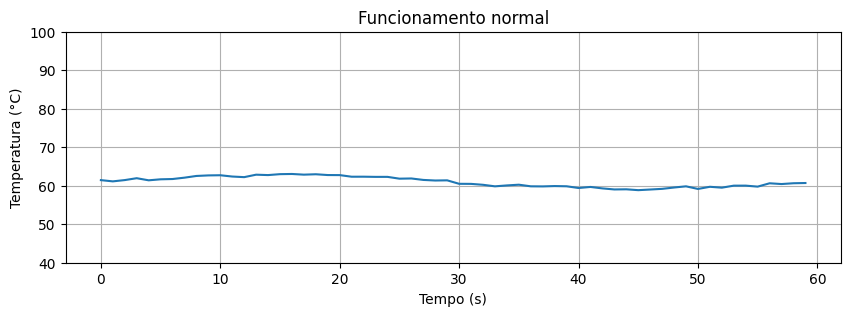

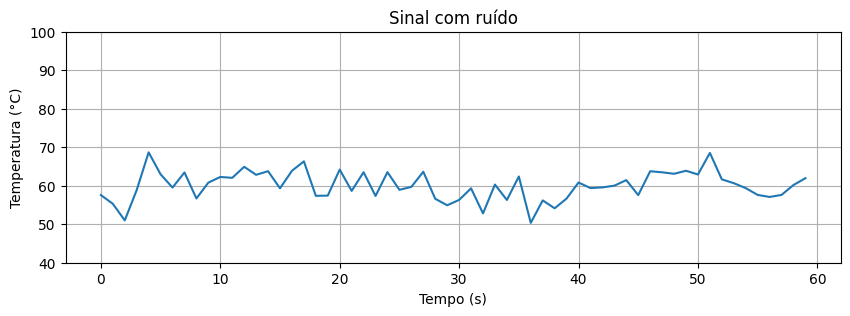

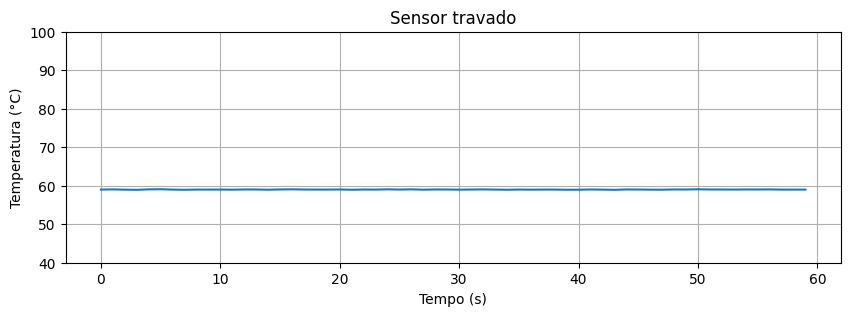

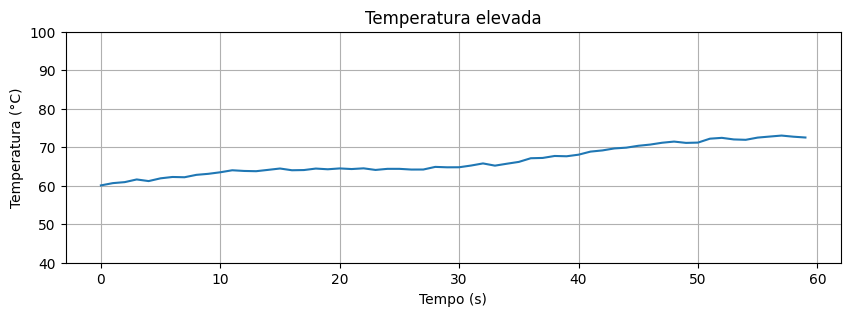

In [61]:
# Gerar um exemplo de cada classe
exemplos = {
    classe: gerar_sinal(classe, rng)
    for classe in nomes_classes
}

# Plotar cada classe em um gráfico separado
for classe, sinal in exemplos.items():
    plt.figure(figsize=(10, 3))
    plt.plot(t, sinal)
    plt.title(nomes_classes[classe])
    plt.xlabel("Tempo (s)")
    plt.ylabel("Temperatura (°C)")
    plt.ylim(40, 100)
    plt.grid(True)
    plt.show()

## 5. Filtragem de Sinais com Média Móvel

Nesta demonstração, utilizaremos um **filtro de média móvel**, que é um filtro FIR passa-baixa simples e eficaz. Ele é ideal para este exemplo porque:

*   **Reduz oscilações rápidas:** Suaviza picos e vales abruptos no sinal.
*   **Preserva tendências lentas:** Mantém as mudanças de longo prazo, que são cruciais para a detecção de condições como temperatura elevada.
*   **Fácil interpretação:** Seu funcionamento é intuitivo, baseado na média de pontos adjacentes.
*   **Conexão com convolução:** Ilustra o conceito de convolução de forma prática.

> **Nota:** A média móvel não é uma solução universal. Em uma aplicação real, a escolha do filtro dependeria de fatores como a dinâmica térmica do equipamento, a taxa de amostragem e o tipo de ruído específico presente no ambiente.

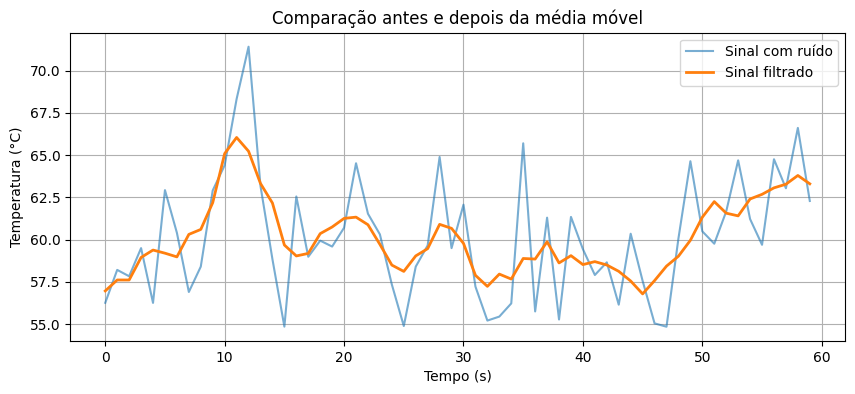

In [50]:
def aplicar_media_movel(
    sinal: np.ndarray,
    janela: int = 5,
) -> np.ndarray:
    """Aplica filtro de média móvel com tratamento simples das bordas.

    Args:
        sinal: Sinal de entrada.
        janela: Quantidade de amostras da janela.

    Returns:
        Sinal suavizado.

    Raises:
        ValueError: Se a janela for menor que 1.
    """
    if janela < 1:
        raise ValueError("A janela deve ser maior ou igual a 1.")

    filtro = np.ones(janela) / janela

    # O preenchimento por repetição reduz o efeito artificial de zeros nas bordas
    esquerda = janela // 2
    direita = janela - 1 - esquerda

    sinal_preenchido = np.pad(
        sinal,
        pad_width=(esquerda, direita),
        mode="edge",
    )

    return np.convolve(
        sinal_preenchido,
        filtro,
        mode="valid",
    )


# Aplicar o filtro ao exemplo com ruído
sinal_ruidoso = exemplos[1]
sinal_filtrado = aplicar_media_movel(
    sinal_ruidoso,
    janela=5,
)

plt.figure(figsize=(10, 4))
plt.plot(
    t,
    sinal_ruidoso,
    label="Sinal com ruído",
    alpha=0.6,
)
plt.plot(
    t,
    sinal_filtrado,
    label="Sinal filtrado",
    linewidth=2,
)
plt.title("Comparação antes e depois da média móvel")
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.legend()
plt.grid(True)
plt.show()

## 6. Extração de Características dos Sinais

Em vez de alimentar o modelo com todas as amostras de cada sinal, o que seria computacionalmente intensivo e propenso a overfitting, cada sinal será resumido por um conjunto de **características numéricas descritivas**. Essas características capturam aspectos importantes do comportamento do sinal.

Serão calculadas as seguintes características para cada sinal:

*   **Média:** Valor central do sinal.
*   **Desvio Padrão:** Medida da dispersão dos dados em torno da média (indicador de ruído).
*   **Valor Máximo:** O pico mais alto atingido pelo sinal.
*   **Valor Mínimo:** O ponto mais baixo atingido pelo sinal.
*   **Amplitude Total:** A diferença entre o valor máximo e o mínimo (indicador de variação).
*   **Energia:** Soma dos quadrados das amostras do sinal (indicador de intensidade).
*   **Inclinação da Tendência:** Obtida através de uma regressão linear simples, indicando a direção e intensidade do crescimento ou decaimento do sinal ao longo do tempo.

In [51]:
def calcular_inclinacao(sinal: np.ndarray) -> float:
    """Calcula a inclinação da tendência linear do sinal.

    Args:
        sinal: Sinal de temperatura.

    Returns:
        Coeficiente angular da reta ajustada.
    """
    coeficientes = np.polyfit(
        t,
        sinal,
        deg=1,
    )
    return float(coeficientes[0])


def extrair_caracteristicas(
    sinal: np.ndarray,
    aplicar_filtro: bool = False,
) -> dict[str, float]:
    """Extrai características temporais de um sinal.

    Args:
        sinal: Sinal de temperatura.
        aplicar_filtro: Se True, aplica média móvel antes da extração.

    Returns:
        Dicionário contendo as características calculadas.
    """
    sinal_processado = (
        aplicar_media_movel(sinal, janela=5)
        if aplicar_filtro
        else sinal
    )

    maximo = float(np.max(sinal_processado))
    minimo = float(np.min(sinal_processado))

    return {
        "media": float(np.mean(sinal_processado)),
        "desvio_padrao": float(np.std(sinal_processado)),
        "maximo": maximo,
        "minimo": minimo,
        "amplitude_total": maximo - minimo,
        "energia": float(np.sum(sinal_processado ** 2)),
        "inclinacao": calcular_inclinacao(sinal_processado),
    }


# Exemplo de características calculadas
for classe, sinal in exemplos.items():
    caracteristicas = extrair_caracteristicas(sinal)
    print(f"\n{nomes_classes[classe]}")
    for nome, valor in caracteristicas.items():
        print(f"{nome}: {valor:.4f}")


Funcionamento normal
media: 61.0706
desvio_padrao: 1.1206
maximo: 62.7158
minimo: 59.1116
amplitude_total: 3.6042
energia: 223852.3162
inclinacao: -0.0093

Sinal com ruído
media: 60.1300
desvio_padrao: 3.5731
maximo: 71.4124
minimo: 54.8467
amplitude_total: 16.5657
energia: 217703.1438
inclinacao: 0.0123

Sensor travado
media: 59.9743
desvio_padrao: 0.0278
maximo: 60.0350
minimo: 59.8952
amplitude_total: 0.1398
energia: 215815.1049
inclinacao: 0.0000

Temperatura elevada
media: 64.4578
desvio_padrao: 2.7203
maximo: 69.2413
minimo: 60.3133
amplitude_total: 8.9280
energia: 249732.2556
inclinacao: 0.1339


## 7. Criação do Conjunto de Dados (Dataset)

Nesta etapa, serão gerados **1000 sinais para cada uma das 4 classes**, totalizando 4000 sinais. Cada sinal será processado para extrair as características definidas anteriormente.

O dataset resultante será uma tabela Pandas DataFrame, onde:

*   Cada **linha** representará um sinal completo e suas características extraídas.
*   Cada **coluna** corresponderá a uma característica (e.g., média, desvio padrão, inclinação).
*   A coluna `classe` será a **variável alvo**, que o modelo de aprendizado de máquina deverá aprender a prever.

In [62]:
dados = []

# Um gerador separado mantém a criação do dataset reproduzível
rng_dataset = np.random.default_rng(SEED)

for classe in range(4):
    for _ in range(n_exemplos_por_classe):
        sinal = gerar_sinal(
            classe,
            rng_dataset,
        )

        caracteristicas = extrair_caracteristicas(
            sinal,
            aplicar_filtro=False,
        )

        caracteristicas["classe"] = classe
        dados.append(caracteristicas)

df = pd.DataFrame(dados)

print(f"Formato do dataset: {df.shape}")

# Exibir 2 exemplos de cada classe
print("\nPrimeiros 2 exemplos de cada classe:")
for classe_id in sorted(df['classe'].unique()):
    print(f"\nClasse {classe_id} ({nomes_classes[classe_id]}):")
    print(df[df['classe'] == classe_id].head(2).to_markdown(index=False))

Formato do dataset: (4000, 8)

Primeiros 2 exemplos de cada classe:

Classe 0 (Funcionamento normal):
|   media |   desvio_padrao |   maximo |   minimo |   amplitude_total |   energia |   inclinacao |   classe |
|--------:|----------------:|---------:|---------:|------------------:|----------:|-------------:|---------:|
| 61.0706 |         1.12057 |  62.7158 |  59.1116 |           3.60421 |    223852 |  -0.00932613 |        0 |
| 60.2364 |         1.2451  |  62.0682 |  58.1697 |           3.89852 |    217799 |  -0.0287535  |        0 |

Classe 1 (Sinal com ruído):
|   media |   desvio_padrao |   maximo |   minimo |   amplitude_total |   energia |   inclinacao |   classe |
|--------:|----------------:|---------:|---------:|------------------:|----------:|-------------:|---------:|
| 59.2405 |         4.73087 |  72.4802 |  46.3192 |           26.1609 |    211909 |   -0.0924619 |        1 |
| 60.2565 |         4.73902 |  70.879  |  47.5825 |           23.2965 |    219198 |   -0.0196056 | 

## 8. Verificação das Médias das Características por Classe

Esta análise exploratória das médias das características por classe é fundamental para entender a distinção entre os grupos **antes** do treinamento do modelo. Ela valida se as características extraídas são realmente informativas para diferenciar as condições.

**Resultados esperados nesta análise:**

*   **Sinal com Ruído:** Espera-se que o **desvio padrão** e a **amplitude total** sejam significativamente maiores devido às oscilações intensas.
*   **Sensor Travado:** O **desvio padrão** e a **amplitude total** devem ser próximos de zero, indicando pouquíssima variação.
*   **Temperatura Elevada:** A **média** geral e a **inclinação** devem ser maiores, refletindo o aumento da temperatura ao longo do tempo.
*   **Funcionamento Normal:** Apresentará valores intermediários para a maioria das características, servindo como baseline.

In [53]:
resumo_classes = (
    df.groupby("classe")
    .mean()
    .round(3)
)

resumo_classes.index = [
    nomes_classes[indice]
    for indice in resumo_classes.index
]

resumo_classes

,media,desvio_padrao,maximo,minimo,amplitude_total,energia,inclinacao
Funcionamento normal,60.134,1.188,61.979,57.964,4.016,217098.377,-0.021
Sinal com ruído,60.162,4.136,69.885,50.490,19.396,218289.603,-0.020
Sensor travado,59.536,0.029,59.604,59.466,0.138,212796.422,0.000
Temperatura elevada,65.155,2.793,70.576,59.954,10.622,255287.016,0.148


## 9. Separação do Dataset em Conjuntos de Treino e Teste

Para garantir a validação robusta do modelo, o dataset será dividido em dois conjuntos distintos:

*   **75% para treinamento:** Utilizado para que o modelo aprenda os padrões e relações entre as características e as classes.
*   **25% para teste:** Reservado para avaliar o desempenho do modelo em dados que ele nunca viu antes, simulando sua aplicação em novas medições.

A **estratificação** é aplicada durante a divisão, o que garante que as proporções das quatro classes sejam mantidas de forma semelhante tanto no conjunto de treino quanto no de teste. Isso evita que uma classe seja sub-representada em um dos conjuntos, o que poderia levar a um modelo enviesado ou com desempenho irreal.

In [54]:
X = df.drop(columns="classe")
y = df["classe"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=SEED,
)

print(f"Amostras de treino: {len(X_train)}")
print(f"Amostras de teste: {len(X_test)}")

Amostras de treino: 3000
Amostras de teste: 1000


## 10. Treinamento do Modelo de Classificação

Para esta demonstração, será utilizado um **Random Forest Classifier**. Este modelo de aprendizado de máquina é uma excelente escolha por diversas razões:

*   **Trabalha bem com dados tabulares:** É eficaz para lidar com datasets onde as entradas são características numéricas organizadas em uma tabela.
*   **Combina várias árvores de decisão:** Reduz o risco de overfitting e melhora a generalização em comparação com uma única árvore.
*   **Não exige padronização das variáveis:** Diferente de outros modelos, o Random Forest é robusto a diferentes escalas de características.
*   **Permite analisar a importância das características:** Oferece um mecanismo para entender quais características contribuíram mais para as decisões de classificação, auxiliando na interpretabilidade do modelo.

In [55]:
modelo = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
)

modelo.fit(
    X_train,
    y_train,
)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


## 11. Avaliação Detalhada do Modelo

A avaliação do modelo será realizada exclusivamente com o **conjunto de teste**, garantindo uma medida imparcial de seu desempenho em dados não vistos. Serão observadas diversas métricas para uma compreensão completa:

*   **Acurácia:** Proporção de previsões corretas sobre o total de previsões.
*   **Precisão (Precision):** Capacidade do modelo de identificar apenas instâncias relevantes (minimizar falsos positivos).
*   **Recall (Revocação):** Capacidade do modelo de encontrar todas as instâncias relevantes (minimizar falsos negativos).
*   **F1-score:** Média harmônica entre precisão e recall, útil para classes desbalanceadas.
*   **Matriz de Confusão:** Representação visual que mostra o número de acertos e erros para cada classe, detalhando onde o modelo está confundindo as classes.

> Como os dados são simulados e as classes foram construídas para serem claramente distintas, é esperado um desempenho elevado do modelo. Contudo, é fundamental lembrar que uma acurácia alta em dados sintéticos **não significa** que o sistema está pronto para uso industrial sem validação extensiva com dados reais.

In [56]:
y_pred = modelo.predict(X_test)

acuracia = accuracy_score(
    y_test,
    y_pred,
)

print(f"Acurácia: {acuracia:.4f}\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            nomes_classes[0],
            nomes_classes[1],
            nomes_classes[2],
            nomes_classes[3],
        ],
    )
)

Acurácia: 1.0000

                      precision    recall  f1-score   support

Funcionamento normal       1.00      1.00      1.00       250
     Sinal com ruído       1.00      1.00      1.00       250
      Sensor travado       1.00      1.00      1.00       250
 Temperatura elevada       1.00      1.00      1.00       250

            accuracy                           1.00      1000
           macro avg       1.00      1.00      1.00      1000
        weighted avg       1.00      1.00      1.00      1000



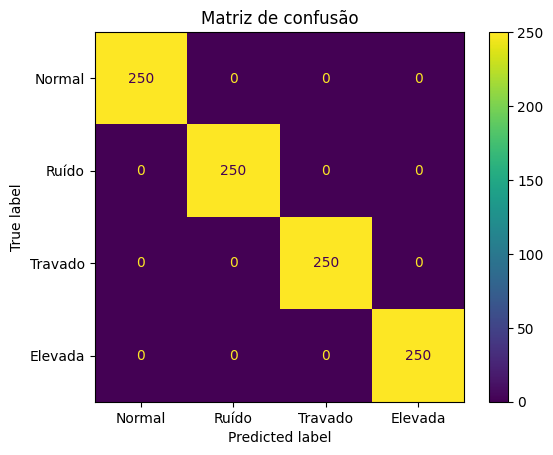

In [57]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "Normal",
        "Ruído",
        "Travado",
        "Elevada",
    ],
)

plt.title("Matriz de confusão")
plt.show()

## 13. Teste com uma Nova Medição (Simulada)

Para simular um cenário de aplicação real, será gerado um **novo sinal de temperatura** que não fez parte dos conjuntos de treinamento ou teste. Este passo valida a capacidade do modelo de generalizar para dados inéditos.

O sistema executará o seguinte fluxo para esta nova medição:

1.  **Extração de Características:** As mesmas características utilizadas no treinamento serão calculadas para o novo sinal.
2.  **Realização da Previsão:** O modelo treinado será usado para classificar o novo sinal em uma das quatro classes.
3.  **Apresentação da Classe Identificada:** Será exibida a condição operacional prevista pelo modelo.
4.  **Exibição das Probabilidades Estimadas:** O modelo também fornecerá a probabilidade de o novo sinal pertencer a cada uma das classes, oferecendo uma medida de confiança na previsão.

Classe real: Temperatura elevada
Classe prevista: Temperatura elevada

Probabilidades:
Funcionamento normal: 0.00%
Sinal com ruído: 0.00%
Sensor travado: 0.00%
Temperatura elevada: 100.00%


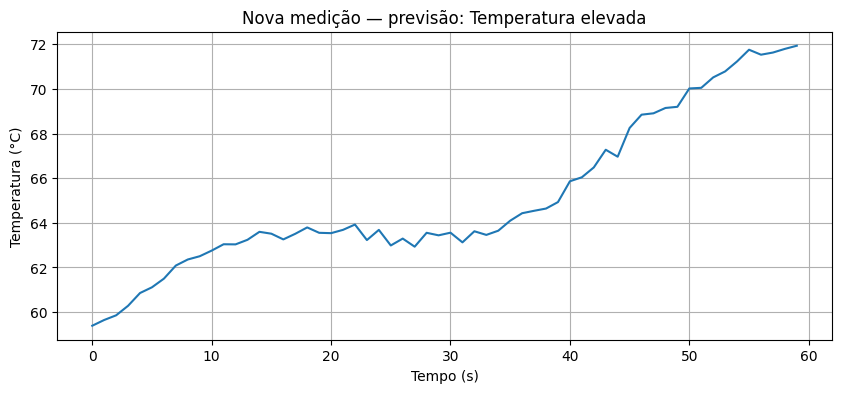

In [59]:
# Escolha uma classe entre 0 e 3 para simular uma nova medição
classe_real = 3

rng_novo = np.random.default_rng(2026)

novo_sinal = gerar_sinal(
    classe_real,
    rng_novo,
)

novas_caracteristicas = extrair_caracteristicas(
    novo_sinal,
    aplicar_filtro=False,
)

novo_df = pd.DataFrame(
    [novas_caracteristicas]
)

previsao = int(
    modelo.predict(novo_df)[0]
)

probabilidades = modelo.predict_proba(
    novo_df
)[0]

print(f"Classe real: {nomes_classes[classe_real]}")
print(f"Classe prevista: {nomes_classes[previsao]}")

print("\nProbabilidades:")
for classe, probabilidade in zip(
    modelo.classes_,
    probabilidades,
):
    print(
        f"{nomes_classes[int(classe)]}: "
        f"{probabilidade:.2%}"
    )

plt.figure(figsize=(10, 4))
plt.plot(t, novo_sinal)
plt.title(
    f"Nova medição — previsão: {nomes_classes[previsao]}"
)
plt.xlabel("Tempo (s)")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()

## 14. Comparação Opcional: Características com e sem Filtragem

A filtragem de sinais é uma etapa comum no PDS, mas sua aplicação deve ser cuidadosamente avaliada. Embora possa **melhorar sinais ruidosos** e facilitar a extração de características, um filtro inadequado também pode **reduzir diferenças úteis** entre as classes, prejudicando a capacidade do modelo de distinguir entre elas.

Em uma aplicação real, é crucial realizar testes para determinar se a filtragem beneficia ou prejudica a classificação. A célula de código abaixo demonstra essa comparação, exibindo as características extraídas do mesmo sinal ruidoso, tanto **antes quanto depois da aplicação do filtro de média móvel**.

In [60]:
comparacao = pd.DataFrame(
    {
        "Sem filtragem": extrair_caracteristicas(
            sinal_ruidoso,
            aplicar_filtro=False,
        ),
        "Com filtragem": extrair_caracteristicas(
            sinal_ruidoso,
            aplicar_filtro=True,
        ),
    }
)

comparacao.round(4)

,Sem filtragem,Com filtragem
media,60.1300,60.1091
desvio_padrao,3.5731,2.1629
maximo,71.4124,66.0429
minimo,54.8467,56.7898
amplitude_total,16.5657,9.2531
energia,217703.1438,217066.9858
inclinacao,0.0123,0.0112


## 15. Interpretação Final e Conclusões

Neste projeto, desenvolvemos um pipeline completo para monitoramento de temperatura industrial, integrando Processamento Digital de Sinais (PDS) e técnicas de Aprendizado de Máquina. O fluxo seguido foi:

**Sensor Simulado → Sinal Digital → Filtragem → Características → Dataset → Modelo → Classificação**

### Papel do PDS (Processamento Digital de Sinais)

O PDS desempenhou um papel fundamental em várias etapas:

*   **Representação do Sinal:** Transformação de dados brutos em um formato digital adequado.
*   **Redução de Ruído:** Através da filtragem, melhorando a qualidade do sinal.
*   **Cálculo de Características:** Extração de métricas que resumem informações importantes.
*   **Resumo do Comportamento Temporal:** Transformação de séries temporais longas em dados concisos e informativos.

### Papel do Aprendizado de Máquina

O aprendizado de máquina utilizou as informações processadas pelo PDS para:

*   **Aprender Padrões:** Identificação de relações complexas entre características e classes.
*   **Classificar Novas Medições:** Previsão da condição operacional de um sinal inédito.
*   **Apoiar a Geração de Alertas:** Fornecendo um mecanismo automático para identificar condições anormais.

### Limitações Desta Demonstração

É importante ressaltar as limitações deste estudo de caso didático, que devem ser consideradas em um contexto industrial real:

*   **Dados Simulados:** A robustez do modelo em dados reais pode variar.
*   **Classes Controladas:** As condições foram construídas para serem claramente distintas, o que pode não ser o caso na realidade.
*   **Ausência de Falhas de Comunicação:** Não foram simulados problemas de transmissão de dados.
*   **Sem Variação entre Sensores:** Não foi considerada a variabilidade intrínseca entre diferentes dispositivos.
*   **Acurácia Elevada Não Garante Desempenho Real:** Modelos com alta acurácia em dados sintéticos precisam de validação rigorosa no campo.
*   **Validação Industrial:** Um sistema para uso industrial exigiria validação extensiva com dados reais, avaliação de falsos positivos e falsos negativos, e consideração de custos de erro.

> **Mensagem Final:** O **PDS** transforma medições brutas em informações úteis, enquanto o **Aprendizado de Máquina** utiliza essas informações para apoiar a tomada de decisões automáticas e inteligentes.